### Overview

This notebook demonstrates how to use `elastic_models` lib to inference optimized FLUX.1-schnell.

For each model, elastic_models provides a series of optimized models:

- XL: Mathematically equivalent neural network, optimized with our DNN compiler.

- L: Near lossless model, with less than 1% degradation obtained on corresponding benchmarks.

- M: Faster model, with quality degradation less than 1.5%.

- S: The fastest model, with quality degradation less than 2%.

To compare model quality for FLUX.1-schnell we used FID score between outputs of original and compressed models

#### Setup environment

Let's start with installing `elastic_models` and `thestage` libs

In [1]:
!pip install elastic_models thestage

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


ERROR: Could not find a version that satisfies the requirement elastic_models (from versions: none)


ERROR: No matching distribution found for elastic_models


Generate thestage access-token. 
See https://docs.thestage.ai/platform/src/thestage-ai-ssh-keys-and-api-tokens.html

Now set up generated token

In [2]:
!thestage config set --access-token <YOUR-THESTAGE-TOKEN>

/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `thestage config set --access-token <YOUR-THESTAGE-TOKEN>'


In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES']="0"

In [4]:
import torch
from elastic_models.diffusers import DiffusionPipeline
import matplotlib.pyplot as plt

/root/.pyenv/versions/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/root/.pyenv/versions/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Loading model

Below we will load flux schnell pipeline by it's huggingface name.

We set `mode="XL"` to use model variant equivalent to the original, optimized with our DNNs compiler

In [5]:
mode_name = "black-forest-labs/FLUX.1-schnell"
device = torch.device("cuda")
pipeline = DiffusionPipeline.from_pretrained(
    mode_name,
    torch_dtype=torch.bfloat16,
    cache_dir="/mount/huggingface_cache",
    mode="XL"
)
pipeline.to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 80.91it/s]


Loading pipeline components...:  43%|████▎     | 3/7 [00:00<00:00, 26.71it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

...

proj_out.bias:   0%|          | 0/4 [00:00<?, ?w/s, dev=cpu]

norm_out.linear.weight:  25%|██▌       | 1/4 [00:00<00:00, 705.99w/s, dev=cpu]

proj_out.weight:  50%|█████     | 2/4 [00:00<00:00, 1107.70w/s, dev=cpu]      

norm_out.linear.bias:  75%|███████▌  | 3/4 [00:00<00:00, 1373.08w/s, dev=cpu]

FluxPipeline {
  "_class_name": "FluxPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "black-forest-labs/FLUX.1-schnell",
  "feature_extractor": [
    null,
    null
  ],
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "T5EncoderModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "T5TokenizerFast"
  ],
  "transformer": [
    "diffusers",
    "FluxTransformer2DModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:00<00:00,  5.05it/s]

100%|██████████| 4/4 [00:00<00:00, 14.72it/s]

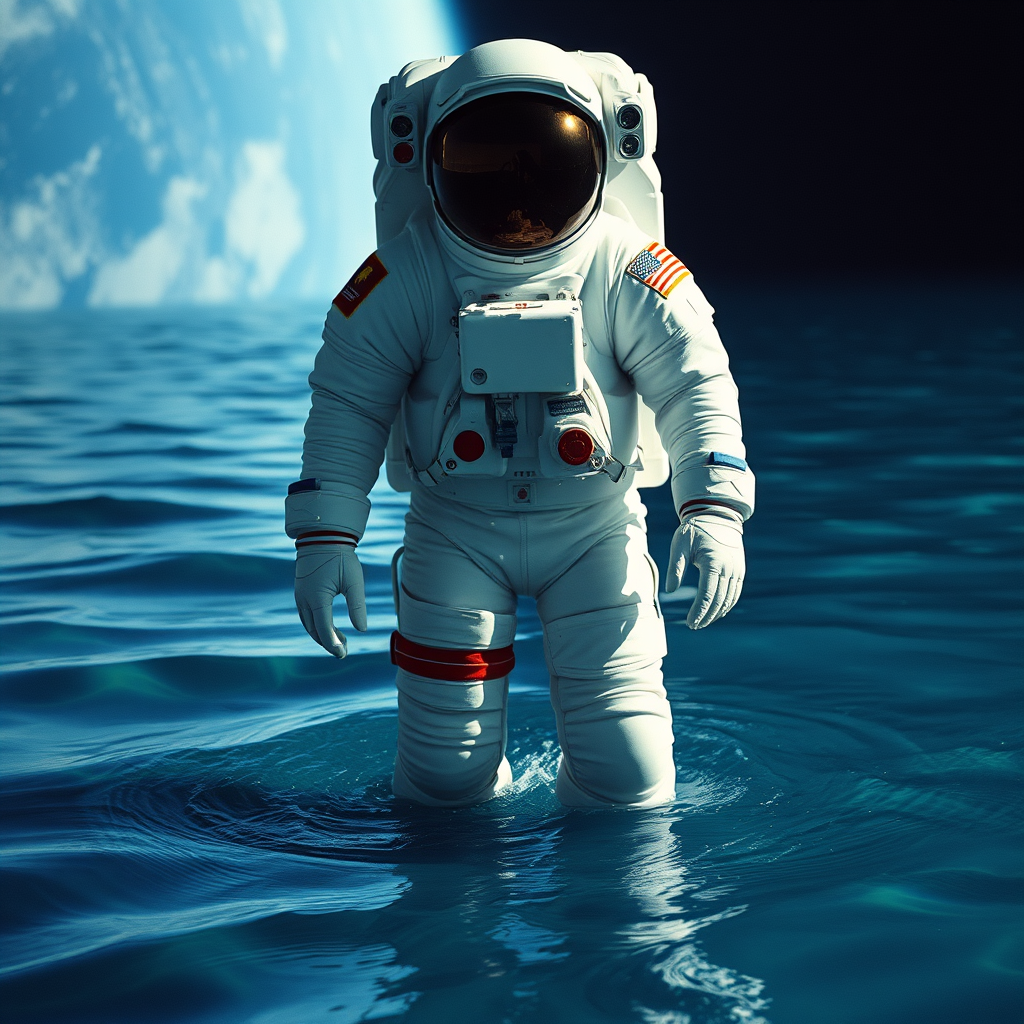

In [6]:
xl_output = pipeline(
    prompt=["An astronaut stands knee-deep in the sea"], 
    num_inference_steps=4,
    generator=torch.Generator(42)
)
xl_output[0][0]

Pre-compiled engines support following image shapes: 512x512, 768x768, 1024x1024.

Let's test image of shape 512x512

  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:01<00:05,  1.73s/it]

100%|██████████| 4/4 [00:01<00:00,  2.21it/s]

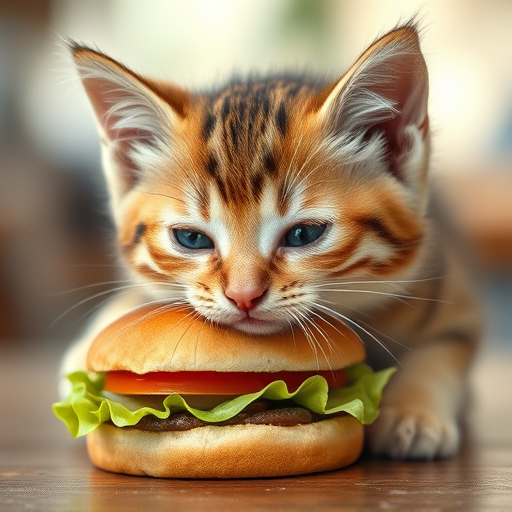

In [7]:
pipeline(
    prompt=["Kitten eating a burger"], 
    height=512, 
    width=512, 
    num_inference_steps=4
)[0][0]

### Benchmark inference time

Let's benchmark inference time and memory usage of the image generation pipeline.

To measure max memory usage we will use `pynvml` lib

In [8]:
import pynvml


def monitor_gpu_memory(queue, running_flag):
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)  # Assuming GPU 0
    max_memory_usage = 0

    try:
        while running_flag.value:
            info = pynvml.nvmlDeviceGetMemoryInfo(handle)
            memory_usage = info.used / (1024 * 1024)  # Convert to MiB
            max_memory_usage = max(max_memory_usage, memory_usage)
    finally:
        pynvml.nvmlShutdown()
        queue.put(max_memory_usage)

When benchmarking inference time, we perform warm-up calls and multiple repetitions to calculate average execution time, while ensuring proper CUDA synchronization.

In [9]:
import timeit

def benchmark_time(pipeline, prompt, number=3, repeat=3, **kwargs):
    run_func = lambda: pipeline(prompt=prompt, **kwargs)
    run_func()
    with torch.no_grad():
        runs = timeit.repeat(
            run_func,
            number=number,
            repeat=repeat,
            setup="import torch; torch.cuda.synchronize()",
        )
    return min(runs) / number

Benchmarks results for `XL` model with different batch sizes:

| Batch size | Inference time (sec) | Max memory usage (GB) |
|------------|----------------------|-----------------------|
| 1          | 0.70255              | 50.2                  |
| 4          | 2.723                | 67.9                  |
| 8          | 5.4082               | 81.5                  |


### Using compressed model

Remove previous model and clear memory

In [10]:
import gc
del pipeline
torch.cuda.empty_cache()
gc.collect();

Set `mode='S'` to load the fastest model variant.

In [11]:
mode_name = "black-forest-labs/FLUX.1-schnell"
device = torch.device("cuda")
pipeline = DiffusionPipeline.from_pretrained(
    mode_name,
    torch_dtype=torch.bfloat16,
    cache_dir="/mount/huggingface_cache",
    mode="S"
)
pipeline.to(device);

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 78.81it/s]


Loading pipeline components...:  43%|████▎     | 3/7 [00:00<00:00, 27.75it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?w/s]

proj_out.bias:   0%|          | 0/4 [00:00<?, ?w/s, dev=cpu]

norm_out.linear.weight:  25%|██▌       | 1/4 [00:00<00:00, 719.81w/s, dev=cpu]

proj_out.weight:  50%|█████     | 2/4 [00:00<00:00, 1128.26w/s, dev=cpu]      

norm_out.linear.bias:  75%|███████▌  | 3/4 [00:00<00:00, 1420.35w/s, dev=cpu]

Let's generate the same image with compressed model and compare it with original one.

  0%|          | 0/4 [00:00<?, ?it/s]

 50%|█████     | 2/4 [00:00<00:00, 17.39it/s]

100%|██████████| 4/4 [00:00<00:00, 24.11it/s]

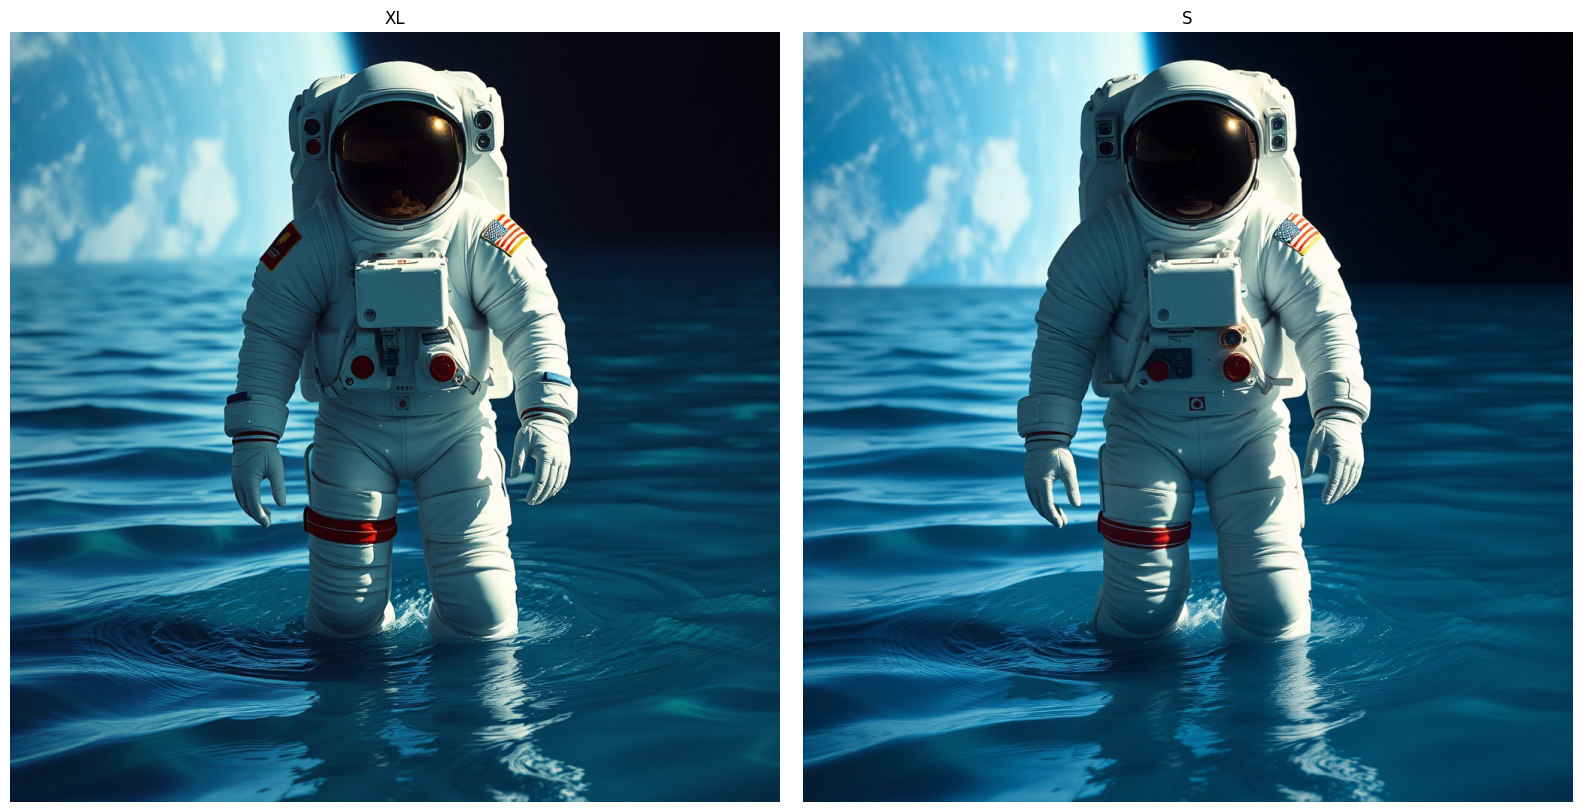

In [12]:
s_output = pipeline(
    prompt=["An astronaut stands knee-deep in the sea"],
    num_inference_steps=4,
    generator=torch.Generator(42)
)

plt.figure(figsize=(16, 8))

for i, image in enumerate([xl_output[0][0], s_output[0][0]]):
    plt.subplot(1, 2, i+1)
    plt.imshow(image)
    plt.title(["XL", "S"][i])
    plt.axis('off')
plt.tight_layout()
plt.show()

Benchmarks results for S model:

| Batch size | Inference time (sec) | Max memory usage (GB) |
|------------|----------------------|-----------------------|
| 1          | 0.4983               | 32.8                  |
| 4          | 1.9589               | 50.5                  |
| 8          | 3.936                | 74.9                  |
